# Machine Learning - Lab 01
## Introduction to ML, Pandas and Visualization

**Part A:** Lab Activity (Titanic + Logistic Regression + `submission.csv`)
**Part B:** Home Activities 1 to 12 (Pandas and Matplotlib)

**Files needed for Part A and Activity 12:** download `train.csv` and `test.csv` from the Kaggle *Titanic* competition and upload them to Colab as `titanic_train.csv` and `titanic_test.csv`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Part A - Lab Activity: Titanic - Machine Learning from Disaster

## Step 1: Load and explore the data

In [ ]:
train = pd.read_csv("Titanic-Dataset.csv")
test = pd.read_csv("titanic_test.csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 2: Check missing values

In [ ]:
print("Train missing values:")
print(train.isnull().sum())
print()
print("Test missing values:")
print(test.isnull().sum())

## Step 3: Visualization - survivors (all passengers, male only, female only)

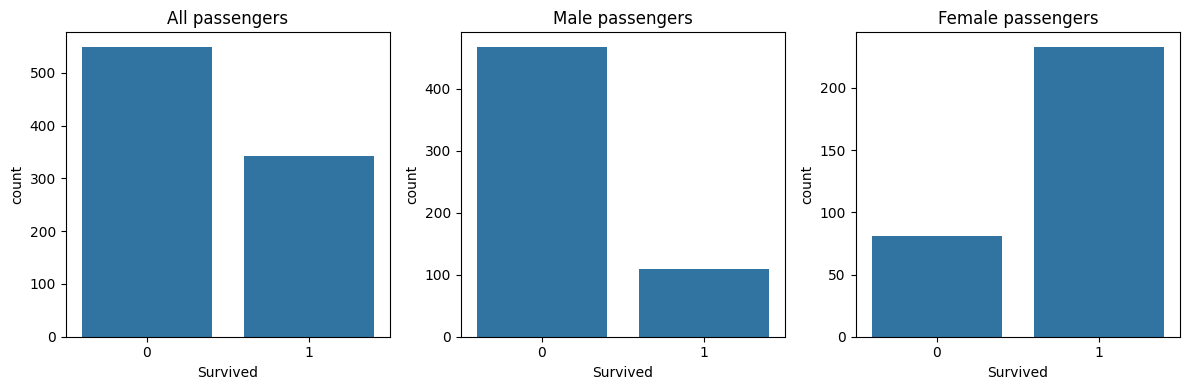

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.countplot(x="Survived", data=train)
plt.title("All passengers")

plt.subplot(1, 3, 2)
sns.countplot(x="Survived", data=train[train["Sex"] == "male"])
plt.title("Male passengers")

plt.subplot(1, 3, 3)
sns.countplot(x="Survived", data=train[train["Sex"] == "female"])
plt.title("Female passengers")

plt.tight_layout()
plt.show()

## Step 4: Clean the data, feature engineering, encode categorical data
- Missing `Age`, `Fare`: fill with the **median** of the training data.
- Missing `Embarked`: fill with the **most common** port.
- New features: `FamilySize` and `IsAlone`.
- `Sex` and `Embarked` are text, so convert them to numbers.

The same function is used for train and test so both get identical columns.

In [ ]:
age_median = train["Age"].median()
fare_median = train["Fare"].median()
embarked_mode = train["Embarked"].mode()[0]

def prepare(df):
    df = df.copy()
    # clean missing values
    df["Age"] = df["Age"].fillna(age_median)
    df["Fare"] = df["Fare"].fillna(fare_median)
    df["Embarked"] = df["Embarked"].fillna(embarked_mode)
    # feature engineering
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
    # categorical -> numerical
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
    df = pd.get_dummies(df, columns=["Embarked"], dtype=int)
    return df

train_clean = prepare(train)
test_clean = prepare(test)
train_clean.head()

## Step 5: Select features, split the training data and train Logistic Regression

In [ ]:
features = ["Pclass", "Sex", "Age", "Fare", "FamilySize", "IsAlone",
            "Embarked_C", "Embarked_Q", "Embarked_S"]

X = train_clean[features]
y = train_clean["Survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Validation accuracy:", round(accuracy_score(y_val, model.predict(X_val)), 3))

## Step 6: Train on all training data and create `submission.csv`

In [ ]:
model.fit(X, y)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": model.predict(test_clean[features])
})
submission.to_csv("submission.csv", index=False)

print(submission.shape)
submission.head()

**To finish the activity:** upload `submission.csv` on the Kaggle competition page and note the score. Then submit on GCR: this `.ipynb` file, a screenshot of the score, and the Kaggle link.

# Part B - Home Activities

## Activity 1: DataFrame of 12 students, inspect index and columns

In [7]:
students = pd.DataFrame({
    "Name": ["Ali", "Sara", "Hamza", "Ayesha", "Bilal", "Zara", "Usman", "Hira", "Omar", "Nida", "Faisal", "Mehak"],
    "Age": [20, 21, 19, 22, 20, 21, 23, 19, 20, 22, 21, 20],
    "City": ["Lahore", "Karachi", "Islamabad", "Lahore", "Karachi", "Islamabad",
             "Lahore", "Karachi", "Islamabad", "Lahore", "Karachi", "Lahore"],
    "Attendance": [92, 85, 70, 95, 60, 88, 75, 90, 65, 98, 80, 72],
    "Marks": [78, 91, 69, 88, 55, 84, 72, 93, 60, 95, 77, 68]
})
print(students)
print()
print("Index:", students.index)
print("Columns:", students.columns)

      Name  Age       City  Attendance  Marks
0      Ali   20     Lahore          92     78
1     Sara   21    Karachi          85     91
2    Hamza   19  Islamabad          70     69
3   Ayesha   22     Lahore          95     88
4    Bilal   20    Karachi          60     55
5     Zara   21  Islamabad          88     84
6    Usman   23     Lahore          75     72
7     Hira   19    Karachi          90     93
8     Omar   20  Islamabad          65     60
9     Nida   22     Lahore          98     95
10  Faisal   21    Karachi          80     77
11   Mehak   20     Lahore          72     68

Index: RangeIndex(start=0, stop=12, step=1)
Columns: Index(['Name', 'Age', 'City', 'Attendance', 'Marks'], dtype='str')


## Activity 2: EDA with `head`, `tail`, `info`, `describe`, `sample`, `value_counts`, `unique`, `shape`, `size`

In [8]:
print(students.head())
print()
print(students.tail())
print()
students.info()
print()
print(students.describe())
print()
print(students.sample(3, random_state=42))
print()
print(students["City"].value_counts())
print()
print("Unique cities:", students["City"].unique())
print("Shape:", students.shape)
print("Size:", students.size)

     Name  Age       City  Attendance  Marks
0     Ali   20     Lahore          92     78
1    Sara   21    Karachi          85     91
2   Hamza   19  Islamabad          70     69
3  Ayesha   22     Lahore          95     88
4   Bilal   20    Karachi          60     55

      Name  Age       City  Attendance  Marks
7     Hira   19    Karachi          90     93
8     Omar   20  Islamabad          65     60
9     Nida   22     Lahore          98     95
10  Faisal   21    Karachi          80     77
11   Mehak   20     Lahore          72     68

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Name        12 non-null     str  
 1   Age         12 non-null     int64
 2   City        12 non-null     str  
 3   Attendance  12 non-null     int64
 4   Marks       12 non-null     int64
dtypes: int64(3), str(2)
memory usage: 612.0 bytes

             Age  Attendance      Ma

**Five observations** (computed from the data):

In [9]:
print("1. The dataset has", students.shape[0], "students and", students.shape[1], "columns, and size =", students.size, "cells.")
print("2. There are no missing values:", students.isnull().sum().sum() == 0)
print("3. The students come from", students["City"].nunique(), "cities; the most common is", students["City"].value_counts().idxmax(), ".")
print("4. Average marks are", round(students["Marks"].mean(), 1), "and the highest is", students["Marks"].max(),
      "(" + students.loc[students["Marks"].idxmax(), "Name"] + ").")
print("5. Attendance and Marks have correlation", round(students["Attendance"].corr(students["Marks"]), 2),
      "- students who attend more tend to score higher.")

1. The dataset has 12 students and 5 columns, and size = 60 cells.
2. There are no missing values: True
3. The students come from 3 cities; the most common is Lahore .
4. Average marks are 77.5 and the highest is 95 (Nida).
5. Attendance and Marks have correlation 0.93 - students who attend more tend to score higher.


## Activity 3: Select columns, `iloc[]` and `loc[]`

In [10]:
print(students["Name"])                      # one column
print(students[["Name", "Marks"]])           # multiple columns

print(students.iloc[0])                      # first row by position
print(students.iloc[2:5, 0:3])               # rows 2-4, first 3 columns
print(students.iloc[4, 4])                   # one cell: row 4, column 4

students_indexed = students.set_index("Name")
print(students_indexed.loc["Sara"])                          # row by label
print(students_indexed.loc[["Ali", "Zara"], ["City", "Marks"]])   # specific rows and columns
print(students_indexed.loc["Hira", "Marks"])                 # one cell by label

0        Ali
1       Sara
2      Hamza
3     Ayesha
4      Bilal
5       Zara
6      Usman
7       Hira
8       Omar
9       Nida
10    Faisal
11     Mehak
Name: Name, dtype: str
      Name  Marks
0      Ali     78
1     Sara     91
2    Hamza     69
3   Ayesha     88
4    Bilal     55
5     Zara     84
6    Usman     72
7     Hira     93
8     Omar     60
9     Nida     95
10  Faisal     77
11   Mehak     68
Name             Ali
Age               20
City          Lahore
Attendance        92
Marks             78
Name: 0, dtype: object
     Name  Age       City
2   Hamza   19  Islamabad
3  Ayesha   22     Lahore
4   Bilal   20    Karachi
55
Age                21
City          Karachi
Attendance         85
Marks              91
Name: Sara, dtype: object
           City  Marks
Name                  
Ali      Lahore     78
Zara  Islamabad     84
93


## Activity 4: Filtering with `&`, `|`, `~`, `^`

In [11]:
# 1. AND (&): good marks AND good attendance
print(students[(students["Marks"] >= 80) & (students["Attendance"] >= 85)])

# 2. OR (|): from Lahore OR very high marks
print(students[(students["City"] == "Lahore") | (students["Marks"] >= 90)])

# 3. NOT (~): everybody who is NOT from Karachi
print(students[~(students["City"] == "Karachi")])

# 4. XOR (^): marks >= 80 OR attendance >= 90, but not both
print(students[(students["Marks"] >= 80) ^ (students["Attendance"] >= 90)])

     Name  Age       City  Attendance  Marks
1    Sara   21    Karachi          85     91
3  Ayesha   22     Lahore          95     88
5    Zara   21  Islamabad          88     84
7    Hira   19    Karachi          90     93
9    Nida   22     Lahore          98     95
      Name  Age     City  Attendance  Marks
0      Ali   20   Lahore          92     78
1     Sara   21  Karachi          85     91
3   Ayesha   22   Lahore          95     88
6    Usman   23   Lahore          75     72
7     Hira   19  Karachi          90     93
9     Nida   22   Lahore          98     95
11   Mehak   20   Lahore          72     68
      Name  Age       City  Attendance  Marks
0      Ali   20     Lahore          92     78
2    Hamza   19  Islamabad          70     69
3   Ayesha   22     Lahore          95     88
5     Zara   21  Islamabad          88     84
6    Usman   23     Lahore          75     72
8     Omar   20  Islamabad          65     60
9     Nida   22     Lahore          98     95
11   Mehak

**Explanation**
- `&` (AND) keeps a row only if **both** conditions are true: students with Marks >= 80 and Attendance >= 85.
- `|` (OR) keeps a row if **at least one** condition is true: students from Lahore, plus anyone with Marks >= 90.
- `~` (NOT) **reverses** a condition: all students whose city is not Karachi.
- `^` (XOR) keeps a row if **exactly one** condition is true: either high marks or high attendance, but not both.

## Activity 5: Add a Grade column, modify a column, drop a column, sort

In [12]:
# add a Grade column (kept in `students`, used later)
students["Grade"] = students["Marks"].apply(lambda m: "A" if m >= 85 else "B" if m >= 70 else "C")

df5 = students.copy()
df5["Marks"] = df5["Marks"] + 2              # modify a numerical column (+2 grace marks)
df5 = df5.drop(columns="Age")                # drop an unnecessary column

print(df5.sort_values("Marks", ascending=True).head(3))     # ascending
print(df5.sort_values("Marks", ascending=False).head(3))    # descending

     Name       City  Attendance  Marks Grade
4   Bilal    Karachi          60     57     C
8    Omar  Islamabad          65     62     C
11  Mehak     Lahore          72     70     C
   Name     City  Attendance  Marks Grade
9  Nida   Lahore          98     97     A
7  Hira  Karachi          90     95     A
1  Sara  Karachi          85     93     A


## Activity 6: Missing values - `isnull()`, `dropna()`, `fillna()`

In [13]:
df6 = students.copy()
df6.loc[[1, 4], "Marks"] = np.nan            # create missing values on purpose
df6.loc[3, "Attendance"] = np.nan

print(df6.isnull().sum())                    # detect

print("Rows after dropna():", len(df6.dropna()), "of", len(df6))     # remove

df6["Marks"] = df6["Marks"].fillna(df6["Marks"].mean())             # replace with mean
df6["Attendance"] = df6["Attendance"].fillna(df6["Attendance"].median())   # replace with median
print(df6.isnull().sum())

Name          0
Age           0
City          0
Attendance    1
Marks         2
Grade         0
dtype: int64
Rows after dropna(): 9 of 12
Name          0
Age           0
City          0
Attendance    0
Marks         0
Grade         0
dtype: int64


## Activity 7: Aggregation on Marks

In [14]:
m = students["Marks"]
print("Sum:", m.sum())
print("Mean:", round(m.mean(), 2))
print("Median:", m.median())
print("Min:", m.min())
print("Max:", m.max())
print("Count:", m.count())
print("Unique values:", m.nunique())
print("Std:", round(m.std(), 2))

Sum: 930
Mean: 77.5
Median: 77.5
Min: 55
Max: 95
Count: 12
Unique values: 12
Std: 13.1


In [15]:
print("Interpretation:")
print("- Mean", round(m.mean(), 1), "and median", m.median(), "are close, so the marks are fairly balanced (no big outliers).")
print("- Std", round(m.std(), 1), "means a typical student is about", round(m.std()), "marks away from the average.")
print("- Marks range from", m.min(), "to", m.max(), "(spread of", m.max() - m.min(), "marks).")

Interpretation:
- Mean 77.5 and median 77.5 are close, so the marks are fairly balanced (no big outliers).
- Std 13.1 means a typical student is about 13 marks away from the average.
- Marks range from 55 to 95 (spread of 40 marks).


## Activity 8: `groupby()` and `agg()`

In [16]:
# three statistics per city
print(students.groupby("City").agg(
    Average_Marks=("Marks", "mean"),
    Highest_Marks=("Marks", "max"),
    Students=("Name", "count")))

# grouping by two columns
print(students.groupby(["City", "Grade"])["Marks"].mean())

           Average_Marks  Highest_Marks  Students
City                                             
Islamabad           71.0             84         3
Karachi             79.0             93         4
Lahore              80.2             95         5
City       Grade
Islamabad  B        84.0
           C        64.5
Karachi    A        92.0
           B        77.0
           C        55.0
Lahore     A        91.5
           B        75.0
           C        68.0
Name: Marks, dtype: float64


## Activity 9: `pivot_table`

In [17]:
pivot = students.pivot_table(values="Marks", index="City", columns="Grade", aggfunc="mean", fill_value=0)
print(pivot)

Grade         A     B     C
City                       
Islamabad   0.0  84.0  64.5
Karachi    92.0  77.0  55.0
Lahore     91.5  75.0  68.0


**Explanation:** each row is a city, each column is a grade, and each cell is the **average marks** of students from that city with that grade. `fill_value=0` shows 0 where no student has that city-grade combination.

## Activity 10: Joins with `merge()` and `join()`

In [18]:
info = pd.DataFrame({"StudentID": [1, 2, 3, 4], "Name": ["Ali", "Sara", "Hamza", "Ayesha"]})
scores = pd.DataFrame({"StudentID": [2, 3, 4, 5], "Score": [91, 69, 88, 70]})

print("INNER (only IDs in both):")
print(pd.merge(info, scores, on="StudentID", how="inner"))
print("OUTER (all IDs from both):")
print(pd.merge(info, scores, on="StudentID", how="outer"))
print("LEFT (all IDs from info):")
print(pd.merge(info, scores, on="StudentID", how="left"))
print("RIGHT (all IDs from scores):")
print(pd.merge(info, scores, on="StudentID", how="right"))

# the left join again using join() (join works on the index)
print("LEFT using join():")
print(info.set_index("StudentID").join(scores.set_index("StudentID"), how="left"))

INNER (only IDs in both):
   StudentID    Name  Score
0          2    Sara     91
1          3   Hamza     69
2          4  Ayesha     88
OUTER (all IDs from both):
   StudentID    Name  Score
0          1     Ali    NaN
1          2    Sara   91.0
2          3   Hamza   69.0
3          4  Ayesha   88.0
4          5     NaN   70.0
LEFT (all IDs from info):
   StudentID    Name  Score
0          1     Ali    NaN
1          2    Sara   91.0
2          3   Hamza   69.0
3          4  Ayesha   88.0
RIGHT (all IDs from scores):
   StudentID    Name  Score
0          2    Sara     91
1          3   Hamza     69
2          4  Ayesha     88
3          5     NaN     70
LEFT using join():
             Name  Score
StudentID               
1             Ali    NaN
2            Sara   91.0
3           Hamza   69.0
4          Ayesha   88.0


## Activity 11: Matplotlib plots (line, scatter, histogram, bar, heatmap, box plot)

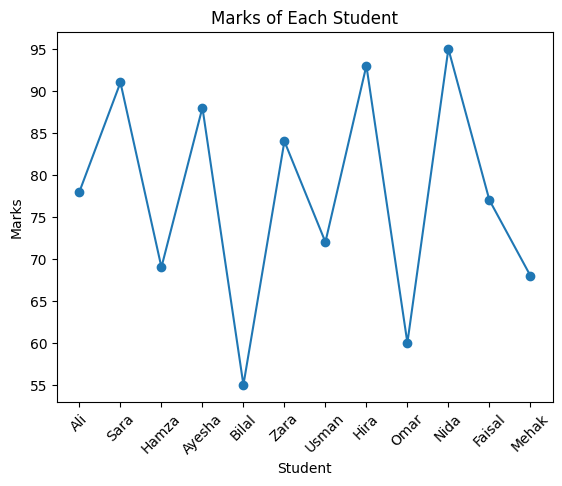

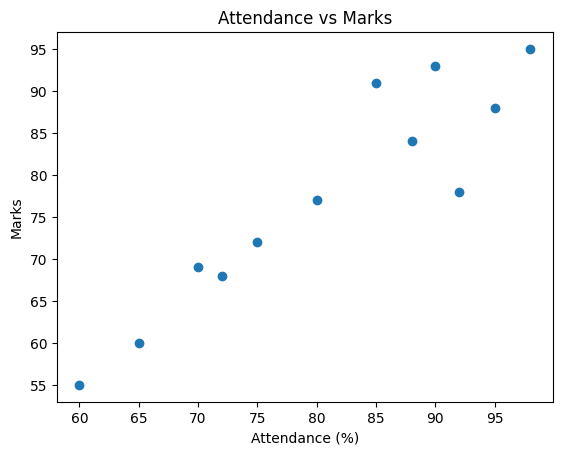

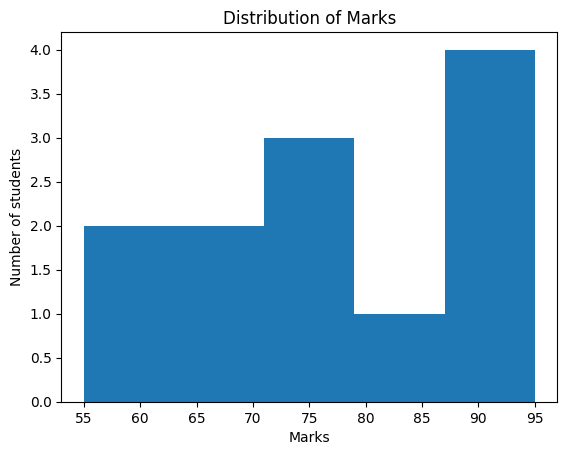

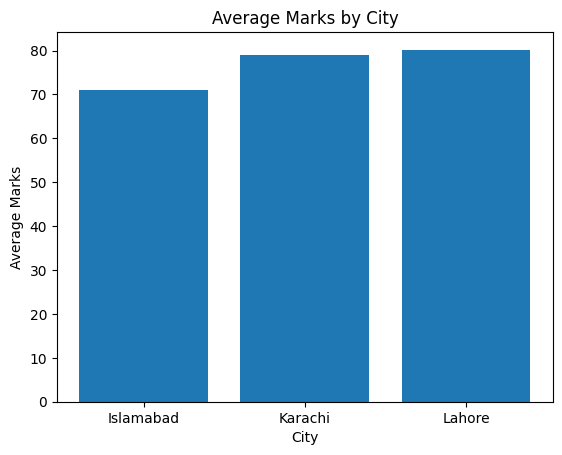

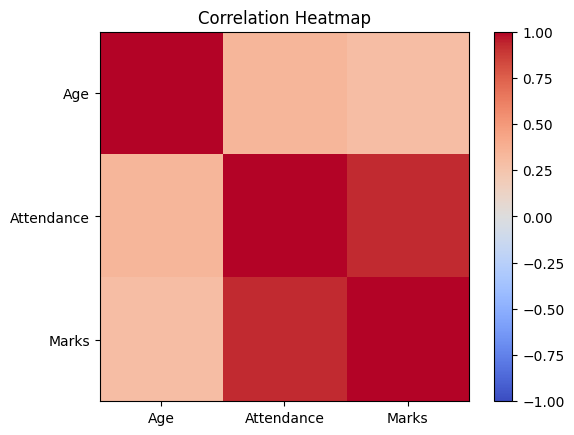

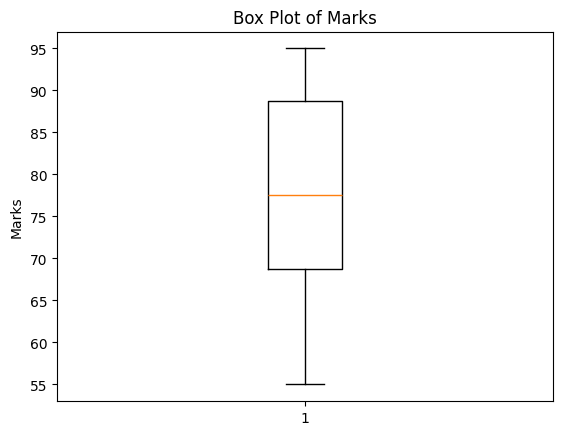

In [19]:
# 1. Line plot
plt.plot(students["Name"], students["Marks"], marker="o")
plt.title("Marks of Each Student")
plt.xlabel("Student")
plt.ylabel("Marks")
plt.xticks(rotation=45)
plt.show()

# 2. Scatter plot
plt.scatter(students["Attendance"], students["Marks"])
plt.title("Attendance vs Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Marks")
plt.show()

# 3. Histogram
plt.hist(students["Marks"], bins=5)
plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of students")
plt.show()

# 4. Bar chart
avg_marks = students.groupby("City")["Marks"].mean()
plt.bar(avg_marks.index, avg_marks.values)
plt.title("Average Marks by City")
plt.xlabel("City")
plt.ylabel("Average Marks")
plt.show()

# 5. Heatmap (correlation)
corr = students[["Age", "Attendance", "Marks"]].corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(3), corr.columns)
plt.yticks(range(3), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

# 6. Box plot
plt.boxplot(students["Marks"])
plt.title("Box Plot of Marks")
plt.ylabel("Marks")
plt.show()

## Activity 12: Integrated EDA task (Titanic CSV)

**Load and inspect**

In [21]:
data = pd.read_csv("Titanic-Dataset.csv")
print(data.shape)
data.info()
print(data.isnull().sum())

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Clean missing values, filter records, create a derived column**

In [22]:
data["Age"] = data["Age"].fillna(data["Age"].median())     # clean
data = data.drop(columns="Cabin")                           # mostly empty column
first_class = data[data["Pclass"] == 1]                     # filter: first-class passengers
print("First-class passengers:", len(first_class))
data["FamilySize"] = data["SibSp"] + data["Parch"] + 1      # derived column

First-class passengers: 216


**Summarize**

In [23]:
print(data.groupby("Sex")["Survived"].mean())
print(data.groupby("Pclass").agg(
    Passengers=("Survived", "count"),
    Survival_Rate=("Survived", "mean"),
    Average_Fare=("Fare", "mean")))

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
        Passengers  Survival_Rate  Average_Fare
Pclass                                         
1              216       0.629630     84.154687
2              184       0.472826     20.662183
3              491       0.242363     13.675550


**Visualizations**

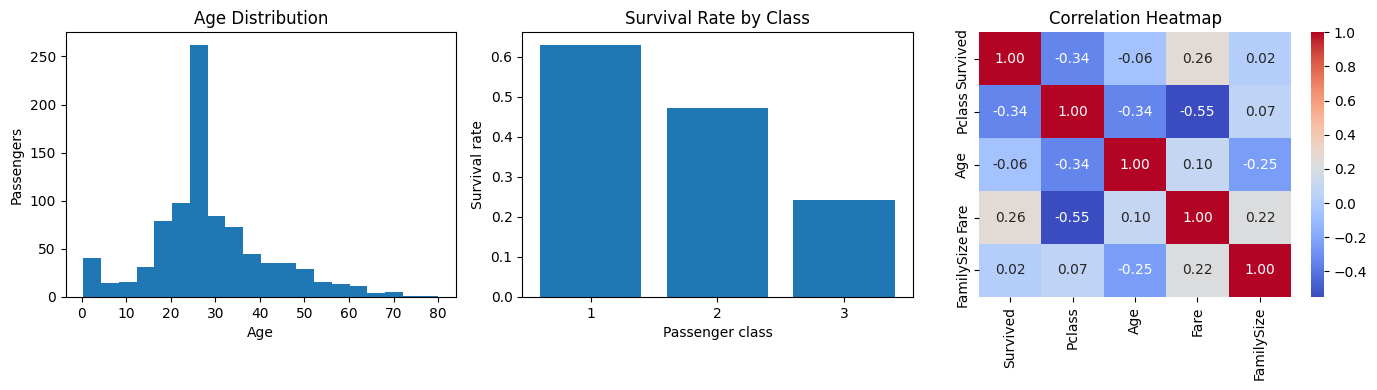

In [24]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(data["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passengers")

plt.subplot(1, 3, 2)
rate = data.groupby("Pclass")["Survived"].mean()
plt.bar(rate.index.astype(str), rate.values)
plt.title("Survival Rate by Class")
plt.xlabel("Passenger class")
plt.ylabel("Survival rate")

plt.subplot(1, 3, 3)
sns.heatmap(data[["Survived", "Pclass", "Age", "Fare", "FamilySize"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()